# __Comparación de la eficacia de distintos métodos de Regresión al predecir el peso de diferentes especies de pescado__

#### Realizado por *Elías Zorrilla Galdón*

## Introducción

Durante este notebook, vamos a utilizar una base de datos que guarda las diferentes medidas de varias especies de pescado en relación a su peso para entrenar dos modelos distintos de machine learning:
- Un modelo de *Regresión múltiple exponencial*
- Un modelo de *Regresión polinomial*

Después compararemos la eficacia de ambos modelos para predecir nuevos outputs con la utilización de __diferentes métricas de error estadistico__.

Por último, desplegaremos y guardaremos el modelo como un archivo `.joblib`

Primero importamos las librerias que vamos a utilizar

## Análisis exploratorio

In [55]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

Leemos el archivo .csv y comprobamos su estructura y agrupamos los datos en base a las especies para ver el valor medio y  el máximo de cada una en las 
diferentes medidas estudiadas.

In [56]:
df = pd.read_csv('../Data/Fish.csv')

In [57]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [58]:
df.groupby('Species').agg('max')

,Weight,Length1,Length2,Length3,Height,Width
Species,,,,,,
Bream,1000.0,38.0,41.0,46.5,18.9570,6.7497
Parkki,300.0,24.0,26.0,29.0,11.3680,4.2340
Perch,1100.0,41.1,44.0,46.6,12.8002,8.1420
Pike,1650.0,59.0,63.4,68.0,10.8120,7.4800
Roach,390.0,29.5,31.7,35.0,9.4850,5.3550
Smelt,19.9,13.8,15.0,16.2,2.9322,2.0672
Whitefish,1000.0,37.3,40.0,43.5,12.3540,6.5736


In [59]:
df.groupby('Species').agg('mean')

,Weight,Length1,Length2,Length3,Height,Width
Species,,,,,,
Bream,617.828571,30.305714,33.108571,38.354286,15.183211,5.427614
Parkki,154.818182,18.727273,20.345455,22.790909,8.962427,3.220736
Perch,382.239286,25.735714,27.892857,29.571429,7.861870,4.745723
Pike,718.705882,42.476471,45.482353,48.717647,7.713771,5.086382
Roach,152.050000,20.645000,22.275000,24.970000,6.694795,3.657850
Smelt,11.178571,11.257143,11.921429,13.035714,2.209371,1.340093
Whitefish,531.000000,28.800000,31.316667,34.316667,10.027167,5.473050


In [60]:
df['Species'].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

Comprobamos que la columna 'Species' es cualitativa y para poder introducirla en nuestro análisis, decido convertirla a __one hot encoding__ creando diferentes dummy columns en un dataset llamado `df_ohe`. 

Para una buena interpretación de los coeficientes, necesitamos eliminar una de las columnas del One Hot Encoding para que no se dé la colinealidad perfecta.
*(Al haber siete columnas de unos y el resto ceros, siempre hay una de ellas que por así decirlo sobra ya que no revela nueva información y es 1 menos la suma de las demás).*
Es por esto que en vez de droppear la primera columna (`drop_first=True`) como suele hacerse normalmente, he eliminado la columna *'Whitefish'* ya que solo tiene 6 datos y es la que menos perjudica al resto del dataset al ser eliminada.

In [61]:
df_ohe = pd.get_dummies(df['Species'],dtype=int)
df_ohe = df_ohe.drop('Whitefish',axis =1)

Concateno `df` y `df_ohe` en el axis 1 creando asi el __DataFrame `fish`__ y elimino la columna 'Species'.

In [62]:
fish=pd.concat([df,df_ohe],axis=1)


In [63]:
fish = fish.drop('Species',axis=1)

In [64]:
fish.head()

,Weight,Length1,Length2,Length3,Height,Width,Bream,Parkki,Perch,Pike,Roach,Smelt
0,242.0,23.2,25.4,30.0,11.5200,4.0200,1,0,0,0,0,0
1,290.0,24.0,26.3,31.2,12.4800,4.3056,1,0,0,0,0,0
2,340.0,23.9,26.5,31.1,12.3778,4.6961,1,0,0,0,0,0
3,363.0,26.3,29.0,33.5,12.7300,4.4555,1,0,0,0,0,0
4,430.0,26.5,29.0,34.0,12.4440,5.1340,1,0,0,0,0,0


Ahora podemos completar el análisis exploratorio llamando a `sns.pairplot()` para comprobar que tipo de relación hay entre las Features y la Respuesta.

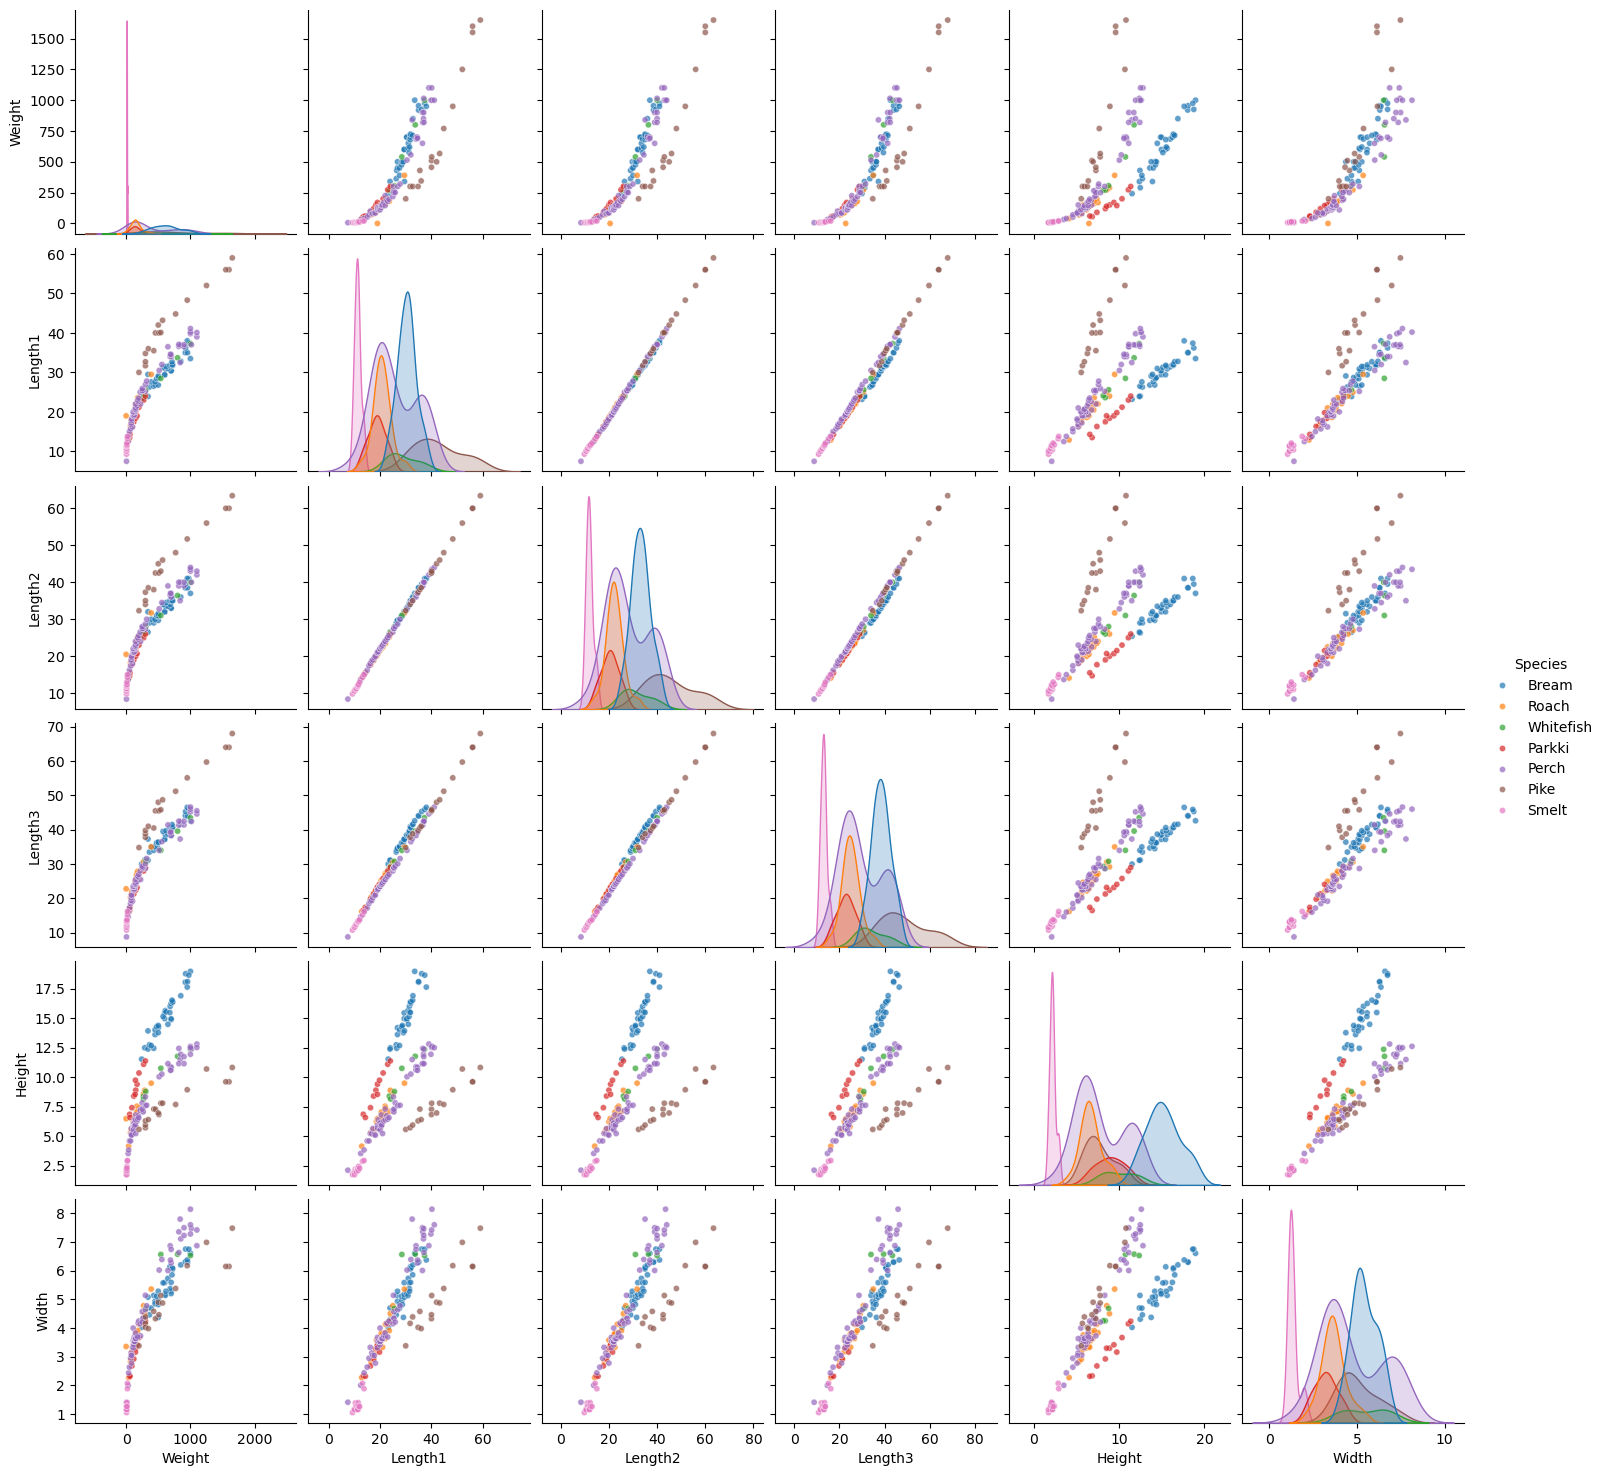

In [65]:
sns.pairplot(df,diag_kind= 'kde' ,hue = 'Species',plot_kws={'s': 20,'alpha':0.7})

En nuestro análisis podemos determinar que __el peso parece relacionarse con las diferentes medidas de los peces de forma exponencial__. También podemos observar cómo esta relación varía bastante por especie y que; por ejemplo, la curva de densidad del peso de Smelt forma un pico muy estrecho debido a que esta especie es la más pequeña y la que menos pesa por lo que las variaciones entre individuos en kgs es mucho menor que en especies más grandes. 

Para nuestro análisis estadístico las variables dependientes e independiente son:
- __Features (Variables dependientes):__ Length1, Length2, Length3, Height,	Width, Bream, Parkki,	Perch, Pike, Roach, Smelt &	Whitefish
- __Response (Variable independiente):__ Weight

## Regresión Exponencial

Debido a que vamos a usar en la respuesta un ajuste logarítmico, necesitamos droppear cualquier fila en la que la respuesta sea <= 0.

In [66]:
fish = fish.loc[fish['Weight']>0,:]

Dividimos las features(X) de la respuesta(y), Importamos el `train/test split` y lo creamos con un `tamaño del test del 30%` y con un `random_state = 42`.

In [67]:
X = fish.drop('Weight',axis = 1)
y = fish.loc[:,'Weight']

In [68]:
from sklearn.model_selection import train_test_split

In [69]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [70]:
from sklearn.linear_model import LinearRegression

Convertimos la respuesta en logarítmica para linealizar las gráficas y poder hacer una regresión linear.

------------------------------------------------------------------------------------------------------------------------------
y = a*e^bx
->
ln(y) = ln(a) + bx

 Y^  = B0 + B1X

That means that a = exp(B0), b = B1 and y = exp(Y^)

------------------------------------------------------------------------------------------------------------------------------

In [71]:
y_train_log = np.log(y_train)

Creo el modelo de regresión lineal, lo entreno con `.fit` y predigo el resultado con `.predict`

In [72]:
exp_model = LinearRegression()

In [73]:
exp_model.fit(X_train,y_train_log)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
exp_prediction = exp_model.predict(X_test)

Devolvemos la respuesta al estado anterior, deshaciendo el ajuste logarítmico de antes

In [75]:
prediction = np.exp(exp_prediction)

## Cálculo de errores en Regresión Exponencial

In [76]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

Calculo el error cuadrático medio, el error medio absoluto y la raíz del error cuadrático medio, además del R^2

In [77]:
MAE_1 = mean_absolute_error(y_test,prediction)
MSE_1 = mean_squared_error(y_test,prediction)
RMSE_1 = root_mean_squared_error(y_test,prediction)
R2_1 = r2_score(y_test,prediction)

## Análisis de Residuales en Regresión Exponencial

Tres gráficos para diagnosticar el modelo:

| Gráfico | Propósito | Lo Ideal | Problemas Clave |
|---------|-----------|----------|-----------------|
| **Residuales vs Predicciones** | Verificar aleatoriedad | Nube dispersa homogénea | Patrones curvos o de embudo |
| **Distribución** | Evaluar normalidad visual | Campana de Gauss centrada | Sesgos o múltiples picos |
| **Q-Q Plot** | Confirmar normalidad | Puntos en línea diagonal | Desviaciones en extremos 

In [78]:
residuals = y_test - prediction

Inicialmente, el modelo exponencial presentaba heterocedasticidad marcada (varianza no constante donde los errores crecían exponencialmente). Para evitar esto apliqué logaritmos a la variable target antes de construir los gráficos.

In [79]:
log_pred = np.log(prediction)
log_y_test = np.log(y_test) 
test_residuals = log_y_test - log_pred

Text(0, 0.5, 'Test residuals')

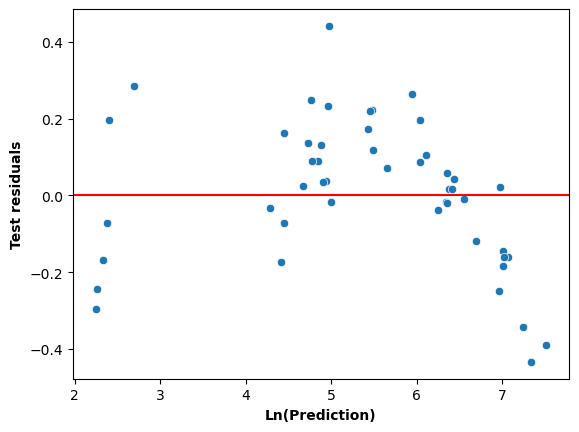

In [80]:
fig,axs = plt.subplots(1,1) 
sns.scatterplot(x=log_pred,y=test_residuals,ax=axs)
axs.axhline(y=0, color='red', linestyle='-')
axs.set_xlabel("Ln(Prediction)",fontweight = 900)
axs.set_ylabel("Test residuals",fontweight = 900)

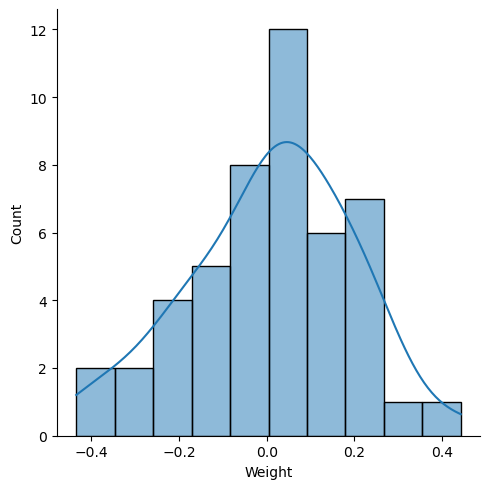

In [81]:
sns.displot(test_residuals,bins=10,kde=True)

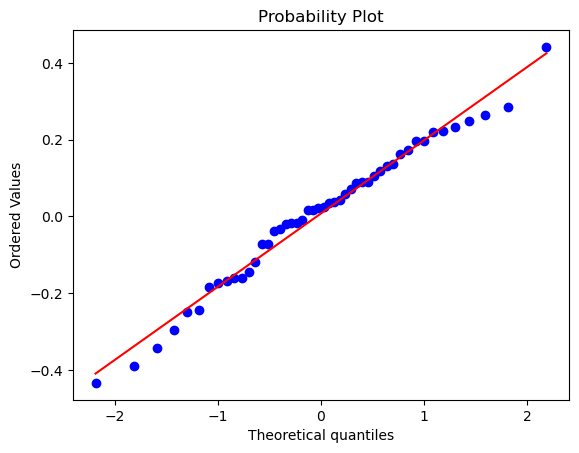

In [82]:
import scipy.stats as st


fig, ax  = plt.subplots(1,1)
_ = st.probplot(test_residuals,plot=ax)

Comprobamos que los residuales se ditribuyen aleatoriamente y normalmente alrededor de 0.

Esto indica que la transformación logarítmica fue efectiva para capturar la relación exponencial subyacente entre las medidas y el peso.

## Regresión Polinomial

Importamos el modelo de regresión polinomial

In [83]:
from sklearn.preprocessing import PolynomialFeatures

Primero de todo, genero un bucle que crea el `train/test` split y que guarda en dos listas, los errores cuadrático medio del test y de los datos de entrenamiento para cada __grado del polinomio__ para saber cual escoger a la hora de entrenar el modelo.

In [84]:
train_rmse_errors = []
test_rmse_errors = []

for d in range(1,6):

    polynomial_converter = PolynomialFeatures(degree = d,include_bias=False)
    poly_features = polynomial_converter.fit_transform(X)

    X_train_test, X_test_test, y_train_test, y_test_test = train_test_split(poly_features, y, test_size=0.3, random_state=42)

    model = LinearRegression()
    model.fit(X_train_test,y_train_test)

    train_pred = model.predict(X_train_test)
    test_pred = model.predict(X_test_test)

    train_rmse = root_mean_squared_error(y_train_test, train_pred)
    test_rmse = root_mean_squared_error(y_test_test, test_pred)
    
    train_rmse_errors.append(train_rmse)
    test_rmse_errors.append(test_rmse)

Comprobamos los errores y creamos una gráfica para visualizar mejor los resultados obtenidos

In [85]:
train_rmse_errors

[94.52616205753696,
 30.428318734870288,
 3.3709993123162287,
 3.3709993123252953,
 3.3709993123162176]

In [86]:
test_rmse_errors

[92.33037735039026,
 91.54608297042834,
 6064.802406460549,
 3748.810989698287,
 5798.2253061598385]

(0.95, 2.2)

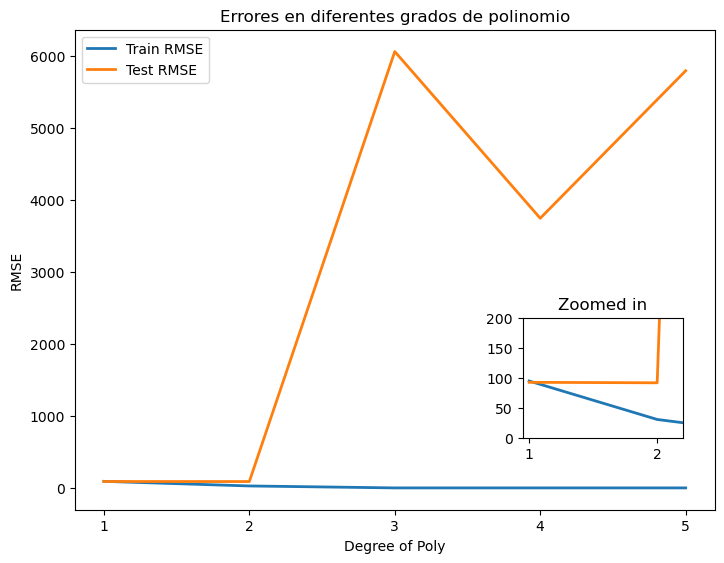

In [87]:
fig = plt.figure()
axes1 = fig.add_axes([0,0,1,1])
axes1.plot(range(1,6),train_rmse_errors[:5],lw=2,label = 'Train RMSE')
axes1.plot(range(1,6),test_rmse_errors[:5],lw=2,label = 'Test RMSE')
axes1.set_title('Errores en diferentes grados de polinomio')
axes1.set_xticks(range(1,6))
axes1.set_xlabel('Degree of Poly')
axes1.set_ylabel('RMSE')
axes1.legend()

axes2 = fig.add_axes([0.7,0.15,0.25,0.25])
axes2.set_title('Zoomed in')
axes2.plot(range(1,6),train_rmse_errors[:5],lw=2)
axes2.plot(range(1,6),test_rmse_errors[:5],lw=2)
axes2.set_xticks(range(1,6))
axes2.set_ylim(0,200)
axes2.set_xlim(0.95,2.2)


Viendo el gráfico, podemos percatarnos de que el error de los datos de entrenamiento solo baja a lo largo del tiempo, mientras que el error con los datos de prueba primero baja y luego se dispara y sube muchísimo conforme aumentamos el grado del ajuste polinomial. Esto es un claro ejemplo del fenómeno de *overfitting*.

Por este motivo para entrenar mi modelo elegiré el grado dos ya que este es el que minimiza ambos errores.

Entreno el modelo polinomial de grado dos, aplicando el `train/test split`:

In [88]:
final_poly_converter = PolynomialFeatures(degree = 2,include_bias=False)
poly_features = final_poly_converter.fit_transform(X)

X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(poly_features, y, test_size=0.3, random_state=42)

poly_model = LinearRegression()
poly_model.fit(X_train_poly,y_train_poly)
test_pred_poly = poly_model.predict(X_test_poly)

Calculo las distintas medidas de error para más tarde compararlas con las que ya tenemos del modelo exponencial y así poder decidir de forma fundamentada qué modelo escoger.

In [89]:
MAE_2 = mean_absolute_error(y_test_poly, test_pred_poly)
MSE_2 = mean_squared_error(y_test_poly, test_pred_poly)
RMSE_2 = root_mean_squared_error(y_test_poly, test_pred_poly)
R2_2 = r2_score(y_test_poly, test_pred_poly)

## Análisis de residuales en modelo Polinomial

Calculo los residuales para analizar como se distribuyen los errores y cual es la magnituda de los mismos.

Los misos tres gráficos para diagnosticar el modelo y compararlo con el exponencial:

| Gráfico | Propósito | Lo Ideal | Problemas Clave |
|---------|-----------|----------|-----------------|
| **Residuales vs Predicciones** | Verificar aleatoriedad | Nube dispersa homogénea | Patrones curvos o de embudo |
| **Distribución** | Evaluar normalidad visual | Campana de Gauss centrada | Sesgos o múltiples picos |
| **Q-Q Plot** | Confirmar normalidad | Puntos en línea diagonal | Desviaciones en extremos 

In [90]:
residuals_poly = y_test_poly - test_pred_poly

Text(0, 0.5, 'Test residuals')

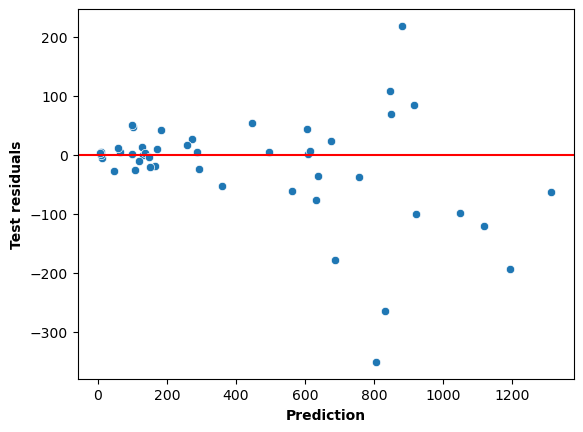

In [91]:
fig,axs = plt.subplots(1,1) 
sns.scatterplot(x=test_pred_poly,y=residuals_poly,ax=axs)
axs.axhline(y=0, color='red', linestyle='-')
axs.set_xlabel("Prediction",fontweight = 900)
axs.set_ylabel("Test residuals",fontweight = 900)

Fijantonos en este gráfico podemos ver que nuestro modelo posee clara heterocedasticidad, lo cual tiene mucho sentido ya que falla más en peces grandes que pesan más y poseen una mayor varianza en peso que especies más pequeñas.

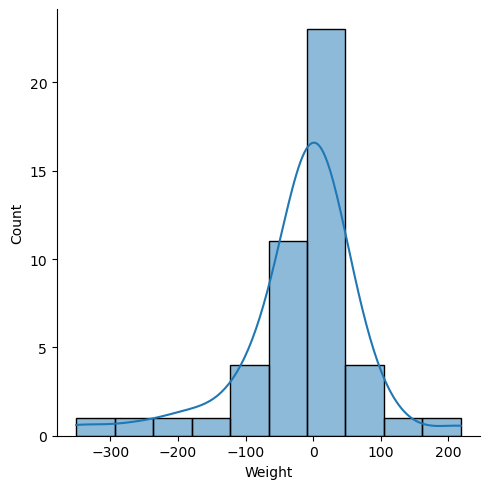

In [92]:
sns.displot(residuals_poly,bins=10,kde=True)

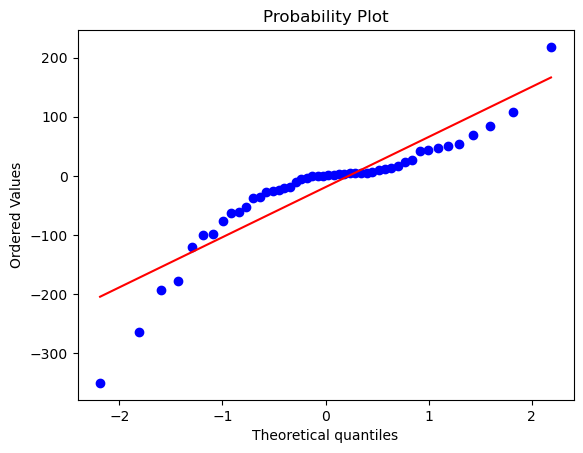

In [93]:
fig, ax  = plt.subplots(1,1)
_ = st.probplot(residuals_poly,plot=ax)

El modelo polinómico puede ajustar bien el promedio, pero las especies grandes generan errores grandes (en magnitud), aunque no en proporción.

Eso rompe la normalidad de los residuos: las colas del Q–Q plot se separan → heterocedasticidad o outliers en los extremos.

## Elección de modelo

Para comparar cada modelo en base a su desempeño, usaremos las cuatro medidas de error calculadas con anterioridad, las cuales dispondremos en el dataframe `df_long`.

In [94]:
df = pd.DataFrame(data = {'Exponencial': [MAE_1,MSE_1,RMSE_1,R2_1], 'Polinomial': [MAE_2,MSE_2,RMSE_2,R2_2],'Error':['MAE','MSE','RMSE','R2']})

In [95]:
df_long = df.melt(id_vars='Error', var_name='Modelo', value_name='Valor')

In [96]:
df

,Exponencial,Polinomial,Error
0,72.500936,54.598696,MAE
1,21729.335470,8380.685307,MSE
2,147.408736,91.546083,RMSE
3,0.823359,0.931872,R2


In [97]:
df_long

,Error,Modelo,Valor
0,MAE,Exponencial,72.500936
1,MSE,Exponencial,21729.335470
2,RMSE,Exponencial,147.408736
3,R2,Exponencial,0.823359
4,MAE,Polinomial,54.598696
5,MSE,Polinomial,8380.685307
6,RMSE,Polinomial,91.546083
7,R2,Polinomial,0.931872


Creamos un gráfico de barras para comparar las métricas de error de una forma más visual.

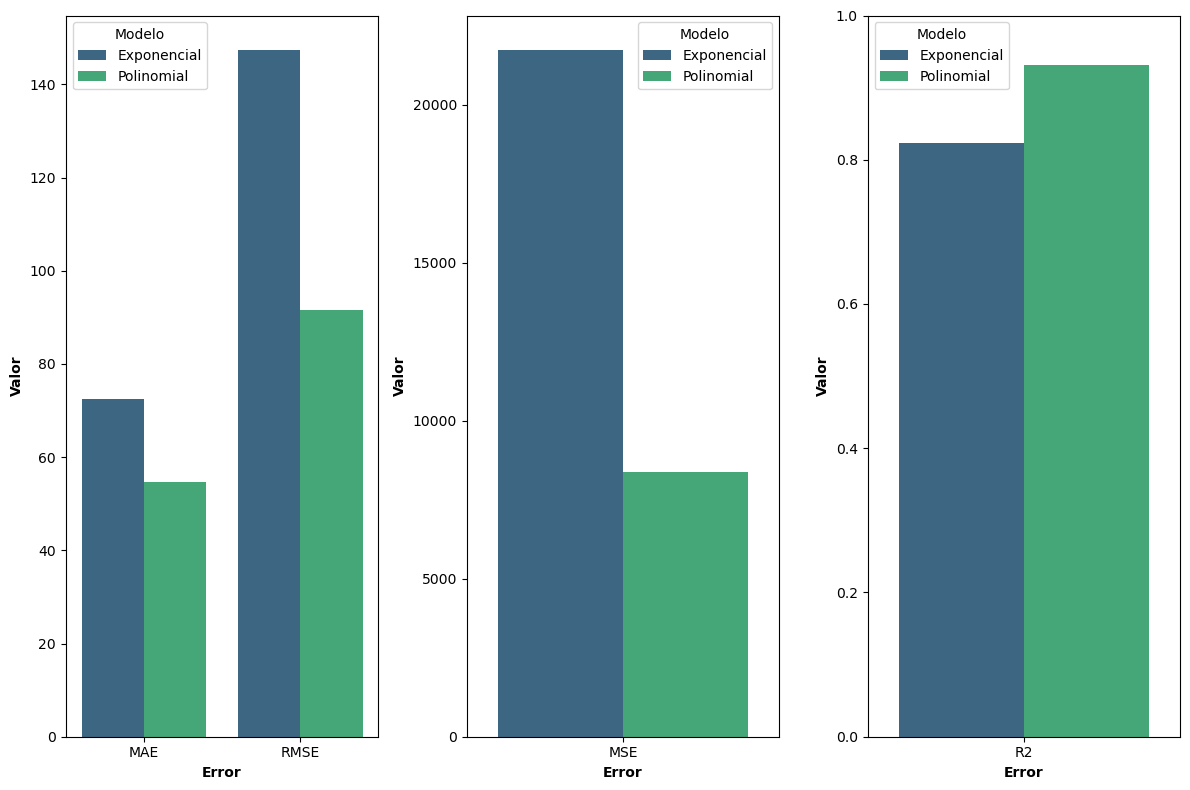

In [98]:
fig,axs = plt.subplots(1,3,figsize=(12,8))
sns.barplot(data = df_long[df_long['Error'].isin(['MAE','RMSE'])],x='Error',y='Valor',hue='Modelo',palette='viridis',ax=axs[0])
sns.barplot(data = df_long[df_long['Error'] == 'MSE'],x='Error',y='Valor',hue='Modelo',palette='viridis',ax=axs[1])
sns.barplot(data = df_long[df_long['Error'] == 'R2'],x='Error',y='Valor',hue='Modelo',palette='viridis',ax=axs[2])
axs[2].set_ylim(0,1)

for ax in axs:
    ax.set_xlabel(ax.get_xlabel(), fontweight='bold')
    ax.set_ylabel(ax.get_ylabel(), fontweight='bold')
plt.tight_layout()

__Ya que el Modelo Polinomial tiene un mejor rendimiento que el exponencial en todas las métricas de error expuestas en el gráfico anterior, he decidido utilizar ese modelo como nuestro modelo definitivo.__

Ahora voy a graficar cómo predice cada modelo el peso , con respecto a la variable 'Length1'.

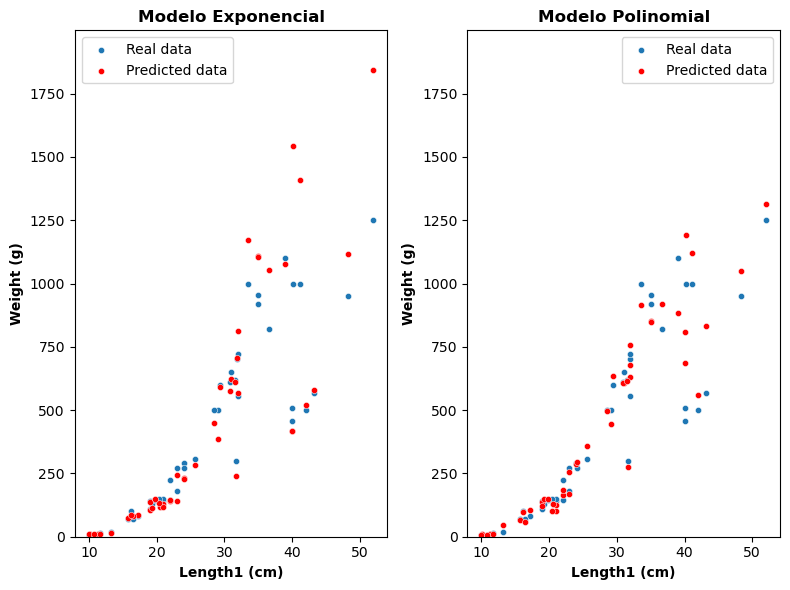

In [99]:
fig,axs = plt.subplots(1,2,figsize=(8,6)) 
sns.scatterplot(x=X_test['Length1'],y=y_test,s=20,ax=axs[0],label = 'Real data') 
sns.scatterplot(x=X_test['Length1'],y=prediction,s=20,color='red',ax=axs[0],label ='Predicted data')
axs[0].set_xlabel("Length1 (cm)",fontweight = 600)
axs[0].set_ylabel("Weight (g)",fontweight = 600)
axs[0].set_title('Modelo Exponencial',fontweight = 1000)
axs[0].set_yticks(range(0,1751,250))
axs[0].set_ylim(0,2000)

sns.scatterplot(x=X_test_poly[:,0],y=y_test_poly,s=20,ax=axs[1],label = 'Real data') 
sns.scatterplot(x=X_test_poly[:,0],y=test_pred_poly,s=20,color='red',ax=axs[1],label ='Predicted data')
axs[1].set_xlabel("Length1 (cm)",fontweight = 600)
axs[1].set_ylabel("Weight (g)",fontweight = 600)
axs[1].set_title('Modelo Polinomial',fontweight = 1000)
axs[1].set_yticks(range(0,1751,250))
axs[1].set_ylim(0,2000)
plt.tight_layout()

__Comprobamos visualmente que el modelo exponencial muestra un patrón de varianza creciente, lo que indica heterocedasticidad más marcada que en el modelo polinomial.__

## Entreno del modelo final y despliegue

__Finalmente, entrenamos el modelo polinomial con la totalidad de los datos que poseemos.__

In [100]:
final_model = LinearRegression()

In [101]:
full_converted_X = final_poly_converter.fit_transform(X)
final_model.fit(full_converted_X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [102]:
from joblib import dump,load

__Guardamos el modelo de predicción polinomial y el conversor en formato `.joblib`.__

In [103]:
dump(final_model,'../Modelos/fish_weight_prediction_poly_model.joblib')

['../Modelos/fish_weight_prediction_poly_model.joblib']

In [104]:
dump(final_poly_converter,'../Modelos/final_converter.joblib')

['../Modelos/final_converter.joblib']

## Conclusión

El análisis mostró que el peso de los peces puede predecirse eficazmente a partir de sus medidas morfológicas.
Entre los modelos evaluados, el polinomial de grado 2 presentó el mejor desempeño, capturando la relación no lineal entre variables sin sesgos significativos en los residuales.

Aunque el modelo final está entrenado y listo para uso, se recomienda:

- Explorar validación cruzada y regularización para mayor robustez.
- Incrementar la cantidad de datos de ciertas especies infrarepresentadas como Parkki y Whitefish.
- Evaluar con datos externos para medir generalización y calcular intervalos de predicción.

En conclusión, el modelo seleccionado es robusto y confiable, y sirve como base sólida para aplicaciones futuras o despliegue en producción.